In [1]:
import pandas as pd
import re
from sentence_transformers import SentenceTransformer
import hdbscan
import json
import umap
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt
import numpy as np

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /usr/local/lib/python3.10/dist-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
2026-06-19 04:24:04.987700: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flag

### Подсчет количества уникальных значений

In [2]:
df = pd.read_csv("classification_atomic.csv")

df["atomic_groups"] = df["atomic_groups"].apply(json.loads)

df_long = (
    df
    .explode("atomic_groups")
    .rename(columns={"atomic_groups": "atomic_group"})
    .dropna(subset=["atomic_group"])
    .reset_index(drop=True)
)

# 2. Нормализация
def normalize_text(x):
    x = str(x).strip().lower()
    x = x.replace("ё", "е")
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[«»\"']", "", x)
    return x

df_long["atomic_group_clean"] = df_long["atomic_group"].apply(normalize_text)

# 3. Частотный список
unique_groups = (
    df_long["atomic_group_clean"]
    .value_counts()
    .reset_index()
)

unique_groups.columns = ["atomic_group_clean", "count"]
unique_groups

,atomic_group_clean,count
0,дети,31997
1,подростки,21253
2,молодежь,16354
3,студенты,14312
4,жители,6465
...,...,...
67119,люди с ограниченными возможностями по слуху и ...,1
67120,представители индустрии туризма и навигации,1
67121,волонтеры молодежных добровольческих движений ...,1
67122,студенты профильных факультетов института куль...,1


### Эмбеддинги

In [3]:
# Эмбеддинги
model = SentenceTransformer("deepvk/USER-base")

embeddings = model.encode(
    unique_groups["atomic_group_clean"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True
)

Default prompt name is set to 'query'. This prompt will be applied to all inference calls, except if a `prompt` or `prompt_name` parameter is provided.
Batches: 100%|██████████| 525/525 [00:36<00:00, 14.23it/s]


### Снижение размерности embeddings

In [4]:
# Снижение размерности embeddings
reducer = umap.UMAP(
    n_neighbors=15,
    n_components=10,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

embeddings_umap = reducer.fit_transform(embeddings)

/home/jupyter/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Определение числа кластеров с помощью метода локтя

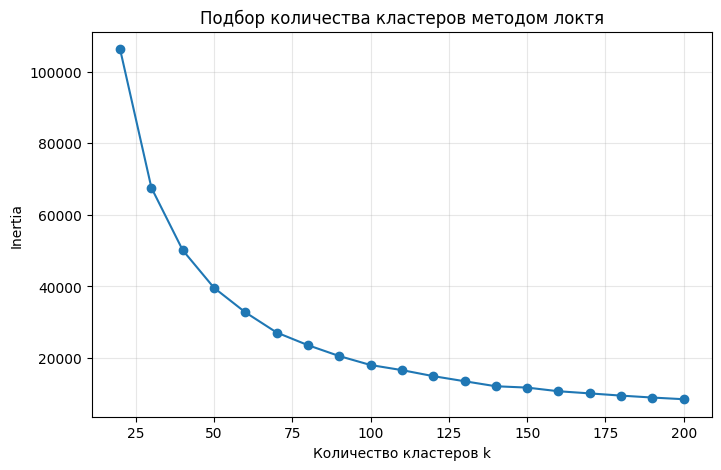

In [5]:
ks = range(20, 201, 10)
inertias = []

for k in ks:
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=4096,
        random_state=42,
        n_init="auto"
    )
    kmeans.fit(embeddings_umap)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("Количество кластеров k")
plt.ylabel("Inertia")
plt.title("Подбор количества кластеров методом локтя")
plt.grid(alpha=0.3)
plt.show()

### Кластеризация

In [6]:
kmeans = MiniBatchKMeans(
    n_clusters=70,
    batch_size=4096,
    random_state=42,
    n_init="auto"
)

unique_groups["category_cluster_kmean"] = kmeans.fit_predict(embeddings_umap)

In [7]:
unique_groups["category_cluster_kmean"].value_counts().sort_values(ascending=False)

category_cluster_kmean
9     2341
2     2281
10    2108
4     1958
6     1625
      ... 
29     218
46     208
66     152
35     112
41     100
Name: count, Length: 70, dtype: int64

### Сохранение статистики по кластерам

In [8]:
def top_examples_with_counts(g, n=80):
    return [
        f'{row["atomic_group_clean"]} ({int(row["count"])})'
        for _, row in g.sort_values("count", ascending=False).head(n).iterrows()
    ]

clusters_for_category = (
    unique_groups
    .groupby("category_cluster_kmean")
    .apply(lambda g: pd.Series({
        "total_count": int(g["count"].sum()),
        "n_variants": int(g["atomic_group_clean"].nunique()),
        "top_examples": " | ".join(top_examples_with_counts(g, 80))
    }))
    .reset_index()
    .sort_values("total_count", ascending=False)
)

clusters_for_category.to_excel("clusters_for_category_naming.xlsx", index=False)
clusters_for_category.to_csv("clusters_for_category_naming.csv", index=False)

/tmp/ipykernel_13344/4283318425.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


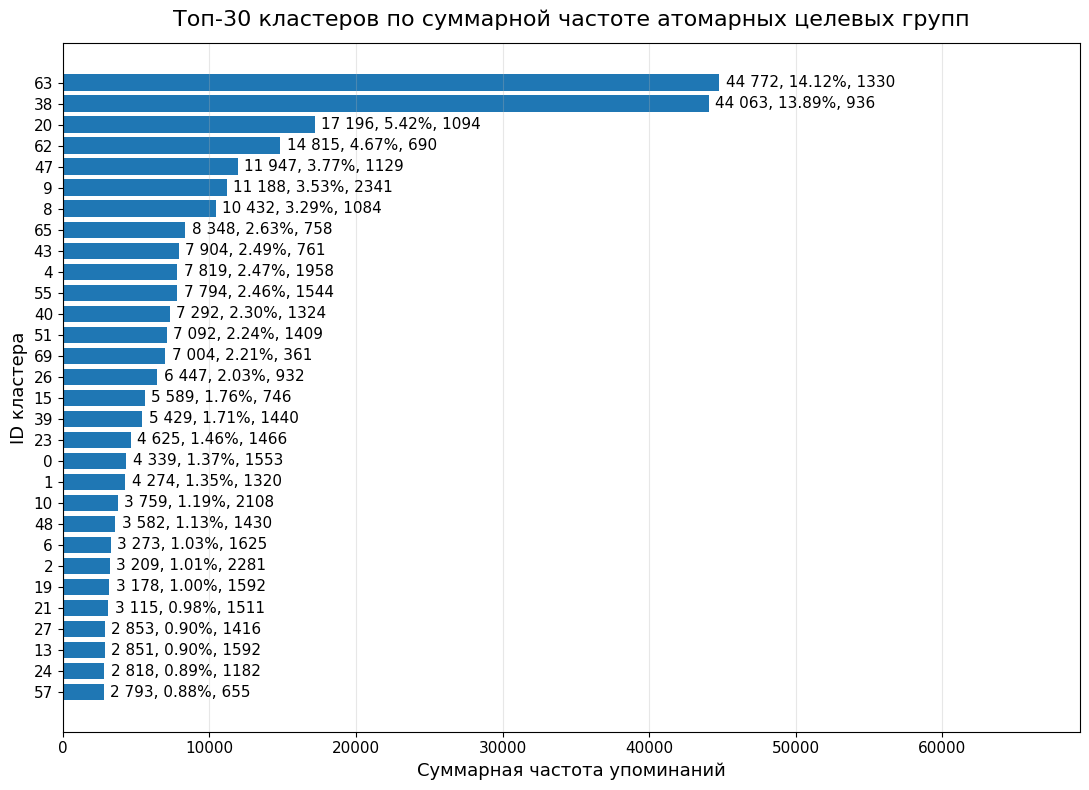

In [11]:
df = clusters_for_category.copy()

df["share_percent"] = (
    df["total_count"] / df["total_count"].sum() * 100
).round(2)

import matplotlib.pyplot as plt

top_n = 30

plot_df = (
    df.sort_values("total_count", ascending=False)
      .head(top_n)
      .sort_values("total_count", ascending=True)
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    plot_df["category_cluster_kmean"].astype(str),
    plot_df["total_count"]
)

plt.title(
    "Топ-30 кластеров по суммарной частоте атомарных целевых групп",
    fontsize=16,
    pad=12
)

plt.xlabel("Суммарная частота упоминаний", fontsize=13)
plt.ylabel("ID кластера", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis="x", alpha=0.3)

max_value = plot_df["total_count"].max()

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    label = (
        f'{int(row["total_count"]):,}'.replace(",", " ")
        + f', {row["share_percent"]:.2f}%'
        + f', {int(row["n_variants"])}'
    )

    plt.text(
        width + max_value * 0.01,
        y,
        label,
        va="center",
        fontsize=11
    )

plt.xlim(0, max_value * 1.55)

plt.tight_layout()
plt.savefig("clusters_with_labels.png", dpi=300, bbox_inches="tight")
plt.show()